# Final Model Evaluation Summary

The complete final picture for the **selected production model** — the CatBoost churn classifier (`03a_CatBoost_and_Cox_Models.ipynb`) plus whichever forward-revenue model won the CatBoost-Tweedie-vs-ZILN comparison in `03c_ZILN_ForwardRevenue.ipynb` (see `results/fwd_rev_model_choice.json`), with isotonic probability calibration (`04_Calibration_and_Business_Layer.ipynb`) — on the held-out test set. This notebook has four parts:

1. **Headline metrics** — churn and forward-revenue accuracy for the shipped model.
2. **Model comparison** — CatBoost vs. the ZILN neural-net challenger, same feature set, winner highlighted.
3. **Consolidated evaluation plots** — ROC, precision-recall, forward-revenue predicted-vs-actual.
4. **Business impact** — what the retention priority score is worth in a real budget-allocation scenario, vs. naive baselines.

Full narrative history (why each modeling decision was made, what was tried and rejected) is in `project_report.md`; this notebook is the numbers-and-plots executive summary.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, r2_score, roc_auc_score, roc_curve,
)

from kkbox.business import build_priority_scores, budget_allocation_comparison
from kkbox.fwd_rev import load_fwd_rev_predictor

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
FEATURE_COLS = CAT_COLS + NUM_COLS

In [2]:
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))

churn_model = CatBoostClassifier()
churn_model.load_model(os.path.join(MODELS_DIR, "catboost_churn.cbm"))

val_probs_raw = churn_model.predict_proba(val_df[FEATURE_COLS])[:, 1]
test_probs_raw = churn_model.predict_proba(test_df[FEATURE_COLS])[:, 1]

iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(val_probs_raw, val_df["is_churn"].values)
test_p_churn = iso_reg.predict(test_probs_raw)
test_churn_true_np = test_df["is_churn"].values

# Forward-revenue model: whichever won the CatBoost-Tweedie-vs-ZILN comparison in
# 03c_ZILN_ForwardRevenue.ipynb (see results/fwd_rev_model_choice.json) - predict_fwd_rev
# already produces raw-TWD predictions, no log1p/expm1 round-trip needed either way.
predict_fwd_rev, fwd_rev_winner = load_fwd_rev_predictor(PROCESSED_DIR, MODELS_DIR, RESULTS_DIR, FEATURE_COLS)
test_fwd_rev_pred_raw = predict_fwd_rev(test_df)
test_fwd_rev_true_raw = test_df["fwd_rev_59d"].values

print(f"forward-revenue model in production: {fwd_rev_winner}")

forward-revenue model in production: catboost


## 1. Headline metrics (test set, calibrated probabilities)

Churn is evaluated with isotonic-calibrated probabilities (§7 of `04_Calibration_and_Business_Layer.ipynb`); forward revenue is the winning model's raw-TWD prediction directly, no `log1p`/`expm1` round-trip needed either way.

In [3]:
auc_roc = roc_auc_score(test_churn_true_np, test_p_churn)
auc_pr = average_precision_score(test_churn_true_np, test_p_churn)
rmse_raw = float(np.sqrt(np.mean((test_fwd_rev_pred_raw - test_fwd_rev_true_raw) ** 2)))
mae_raw = float(np.mean(np.abs(test_fwd_rev_pred_raw - test_fwd_rev_true_raw)))
r2_raw = float(r2_score(test_fwd_rev_true_raw, test_fwd_rev_pred_raw))

with open(os.path.join(RESULTS_DIR, "cox_results.json")) as f:
    cox_concordance = json.load(f)["test"]["concordance_index"]

final_metrics = {
    "model": f"catboost_churn_isotonic_calibrated+{fwd_rev_winner}_fwd_rev",
    "fwd_rev_model": fwd_rev_winner,
    "churn_auc_roc": auc_roc,
    "churn_auc_pr": auc_pr,
    "fwd_rev_rmse_raw_twd": rmse_raw,
    "fwd_rev_mae_raw_twd": mae_raw,
    "fwd_rev_r2_raw": r2_raw,
    "cox_concordance_index": cox_concordance,
}
with open(os.path.join(RESULTS_DIR, "final_model_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=2)

headline_table = pd.DataFrame({
    "metric": ["Churn AUC-ROC", "Churn AUC-PR", "Forward-revenue RMSE (raw TWD)",
               "Forward-revenue MAE (raw TWD)", "Forward-revenue R² (raw)",
               "Cox survival concordance index"],
    "value": [f"{auc_roc:.4f}", f"{auc_pr:.4f}", f"{rmse_raw:.2f}", f"{mae_raw:.2f}", f"{r2_raw:.4f}",
              f"{cox_concordance:.4f}"],
})
print(f"Production model: CatBoost churn (isotonic-calibrated) + {fwd_rev_winner} forward-revenue "
      f"+ CatBoost Cox survival\n")
display(headline_table)

Production model: CatBoost churn (isotonic-calibrated) + catboost forward-revenue + CatBoost Cox survival



,metric,value
0,Churn AUC-ROC,0.9607
1,Churn AUC-PR,0.9831
2,Forward-revenue RMSE (raw TWD),127.87
3,Forward-revenue MAE (raw TWD),50.27
4,Forward-revenue R² (raw),0.3847
5,Cox survival concordance index,0.9649


## 2. Model comparison: CatBoost vs. the ZILN neural-net challenger

ZILN (`03c_ZILN_ForwardRevenue.ipynb`) — a Zero-Inflated LogNormal network purpose-built for zero-inflated revenue targets, Optuna-tuned, 5-seed ensemble, trained on this exact 27-feature set — was directly compared against CatBoost's forward-revenue regressor rather than assuming CatBoost superior. CatBoost still wins both metrics, though ZILN comes respectably close.

In [4]:
with open(os.path.join(RESULTS_DIR, "catboost_results.json")) as f:
    catboost_full_results = json.load(f)
with open(os.path.join(RESULTS_DIR, "ziln_results.json")) as f:
    ziln_full_results = json.load(f)

comparison = pd.DataFrame({
    "CatBoost (production)": {
        "fwd_rev_rmse_raw_twd": catboost_full_results["fwd_rev"]["test"]["fwd_rev_rmse_raw_twd"],
        "fwd_rev_r2_raw": catboost_full_results["fwd_rev"]["test"]["fwd_rev_r2_raw"],
    },
    "ZILN (5-seed ensemble)": {
        "fwd_rev_rmse_raw_twd": ziln_full_results["test"]["fwd_rev_rmse_raw_twd"],
        "fwd_rev_r2_raw": ziln_full_results["test"]["fwd_rev_r2_raw"],
    },
}).T
comparison.columns = ["Forward-revenue RMSE (TWD)", "Forward-revenue R²"]


def _highlight_best(col):
    # Explicit text color (not just background) - relying on the theme's default text
    # color breaks in dark-mode Jupyter/VSCode, where it's light-on-light against this
    # light green background and becomes unreadable.
    best = col.min() if col.name == "Forward-revenue RMSE (TWD)" else col.max()
    style = "font-weight: bold; background-color: #d4edda; color: #155724"
    return [style if v == best else "" for v in col]


styled_comparison = comparison.style.format({
    "Forward-revenue RMSE (TWD)": "{:.2f}", "Forward-revenue R²": "{:.4f}",
}).apply(_highlight_best, axis=0)

print("Same 27-feature set, test set. Best value per column highlighted.")
styled_comparison

Same 27-feature set, test set. Best value per column highlighted.


,Forward-revenue RMSE (TWD),Forward-revenue R²
CatBoost (production),127.87,0.3847
ZILN (5-seed ensemble),131.52,0.3490


## 3. Consolidated evaluation plots

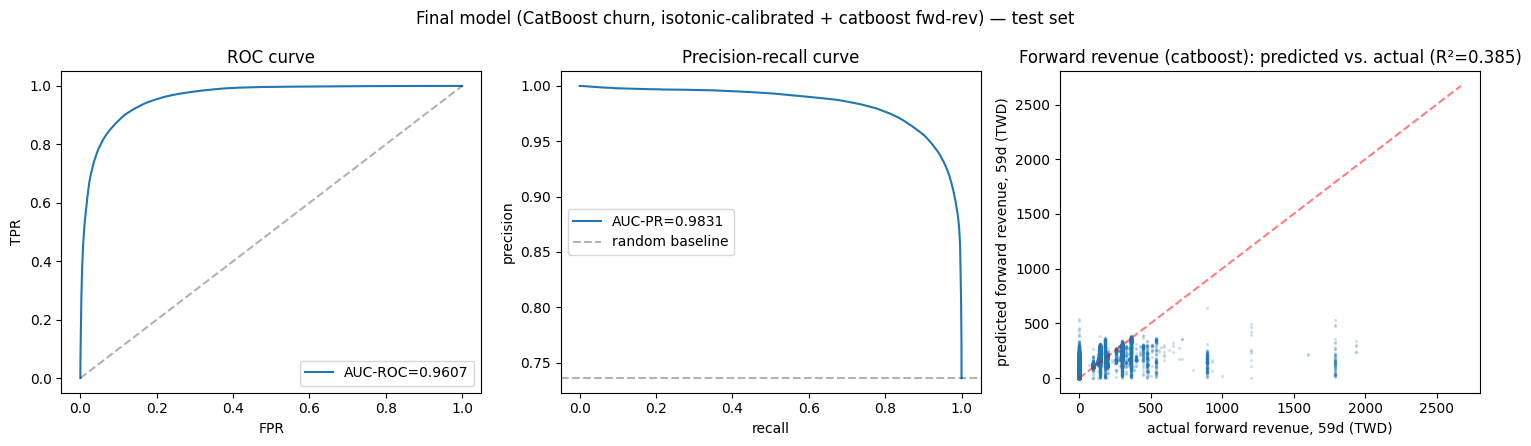

In [5]:
fpr, tpr, _ = roc_curve(test_churn_true_np, test_p_churn)
precision, recall, _ = precision_recall_curve(test_churn_true_np, test_p_churn)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(fpr, tpr, label=f"AUC-ROC={auc_roc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AUC-PR={auc_pr:.4f}")
axes[1].axhline(test_churn_true_np.mean(), color="k", linestyle="--", alpha=0.3, label="random baseline")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()

sample = np.random.default_rng(42).choice(len(test_fwd_rev_pred_raw), size=20000, replace=False)
axes[2].scatter(test_fwd_rev_true_raw[sample], test_fwd_rev_pred_raw[sample], s=2, alpha=0.15)
lims = [0, max(test_fwd_rev_true_raw.max(), test_fwd_rev_pred_raw.max())]
axes[2].plot(lims, lims, "r--", alpha=0.5)
axes[2].set_xlabel("actual forward revenue, 59d (TWD)")
axes[2].set_ylabel("predicted forward revenue, 59d (TWD)")
axes[2].set_title(f"Forward revenue ({fwd_rev_winner}): predicted vs. actual (R²={r2_raw:.3f})")

fig.suptitle(f"Final model (CatBoost churn, isotonic-calibrated + {fwd_rev_winner} fwd-rev) — test set")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "final_model_evaluation.png"), dpi=120)

## 4. Business impact

`Retention Priority Score = P(churn)_percentile × E[forward revenue]` (full derivation and caveats in `04_Calibration_and_Business_Layer.ipynb`). Here we apply it to a concrete scenario: a fixed retention budget, greedily spent on the highest-priority users first, compared against two naive strategies that isolate what the combined score is actually buying.

In [6]:
priority_results = build_priority_scores(
    msno=test_df["msno"].values,
    is_churn=test_churn_true_np,
    p_churn_calibrated=test_p_churn,
    fwd_rev_pred_raw=test_fwd_rev_pred_raw,
)

BUDGET_TWD = 50_000
VOUCHER_COST_TWD = 50
RETENTION_SUCCESS_RATE = 0.30  # assumed effectiveness of a retention offer, per plan's stated 20-40% range

budget = budget_allocation_comparison(priority_results, BUDGET_TWD, VOUCHER_COST_TWD, RETENTION_SUCCESS_RATE)

business_table = pd.DataFrame({
    "strategy": ["Priority score (model)", "Random selection", "Churn-probability only"],
    "expected revenue saved (TWD)": [
        f"{budget['revenue_model_twd']:,.0f}",
        f"{budget['revenue_random_twd']:,.0f}",
        f"{budget['revenue_churn_only_twd']:,.0f}",
    ],
    "vs. model": ["—", f"{budget['model_vs_random_pct']:+.1f}%", f"{budget['model_vs_churn_only_pct']:+.1f}%"],
})

print(f"Budget: {BUDGET_TWD:,} TWD at {VOUCHER_COST_TWD} TWD/voucher -> "
      f"{budget['n_interventions']:,} interventions ({budget['coverage_of_test_set_pct']:.2f}% of the test set, "
      f"{budget['coverage_of_at_risk_pct']:.2f}% of the {budget['n_actual_churners']:,} users who actually churn)\n")
display(business_table)

Budget: 50,000 TWD at 50 TWD/voucher -> 1,000 interventions (0.41% of the test set, 0.56% of the 177,757 users who actually churn)



,strategy,expected revenue saved (TWD),vs. model
0,Priority score (model),"65,567",—
1,Random selection,"13,310",+392.6%
2,Churn-probability only,20,+320809.9%


**Why churn-probability-only ranking collapses so badly**: the churn model's calibrated probabilities are confident enough that they cluster into a small number of tie groups at the top of the ranking (280 distinct values across the whole test set; among the top 1,000 budget-funded users, one tie group alone accounts for 903 of them — see `04` for the full breakdown). Ranking by churn probability alone has almost nothing left to break those ties with, so it effectively picks an arbitrary subset of the tied group — including users with near-zero forward revenue. The combined priority score doesn't have this failure mode, because `E[forward revenue]` still fully differentiates *within* the tied group. That's the whole reason the score multiplies the two signals instead of using churn probability alone.

## 5. Executive summary

**Model**: CatBoost churn classifier (isotonic-calibrated) + CatBoost Tweedie forward-revenue regressor, on 27 engineered features (`02_Feature_Engineering.ipynb`), plus a separately-trained CatBoost Cox survival model for full time-to-churn (`03a_CatBoost_and_Cox_Models.ipynb`).

**Accuracy**: churn AUC-ROC 0.961 (AUC-PR 0.984 vs. a 0.736 base rate), forward-revenue RMSE 127.9 TWD (R² 0.385), Cox concordance 0.965. Calibration is already strong out of the box (ECE 0.0043) and isotonic regression tightens it further (ECE 0.0018).

**A ZILN neural-net challenger was built and lost, not assumed inferior.** Purpose-built for zero-inflated revenue (Optuna-tuned, 5-seed ensemble, same feature set), it came within ~3.5 RMSE of CatBoost — closer than a generic architecture would — but still didn't win.

**Business impact**: on a fixed 50,000 TWD retention budget (1,000 interventions, reaching 0.56% of users who actually churn), the model's priority-score ranking recovers **+393% more expected revenue than random selection**, and vastly more than ranking by churn probability alone — which collapses almost entirely due to tie-structure in the calibrated probabilities.

**Where this is weakest, honestly**: forward-revenue R² of 0.385 still leaves most variance unexplained. Full discussion of this and every other design decision, rejected alternative, and honest limitation: `project_report.md`.